モデルのインポート

In [17]:
from dataclasses import dataclass
from enum import Enum
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from joblib import Parallel, delayed
from collections import Counter
import os
import json
import time

In [18]:
from pathlib import Path
import sys

# 今の作業フォルダを確認
print("current folder:", Path.cwd())

# fig3.ipynb が fig3 フォルダ内で動いている想定
PROJECT_ROOT = Path.cwd().parent

# 親フォルダを import 対象に追加
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rumor_model import *

current folder: c:\Users\yushi\Documents\図齋ゼミ\研究\進化するシステム\fig3


In [19]:
# =========================
# Fig.3 本番用 設定
# =========================

T_VALUES = [100, 200, 300, 400] + list(range(600, 2001, 200))
R_VALUES = list(range(0, 11))

G = 5
N = 40

REPEAT = 100              # 論文に寄せるなら100
MAX_GENERATIONS = 200    # 重すぎるなら100や200に下げる
N_JOBS = 4                # Ryzen 5700X系ならまず6。余裕あれば8
CHUNK_SIZE = 12           # 途中保存単位。小さいほど安全、大きいほど少し速い

CHECKPOINT_PATH = "fig3_trials_checkpoint.csv"
SUMMARY_PATH = "fig3_summary_checkpoint.csv"
META_PATH = "fig3_run_config.json"
BASE_SEED = 20260608

In [20]:
def make_task_key(T, r, rep, seed):
    return f"T={int(T)}__r={int(r)}__rep={int(rep)}__seed={int(seed)}"


def run_one_trial_fig3_task(task, max_generations=500):
    T = int(task["T"])
    r = int(task["r"])
    rep = int(task["rep"])
    seed = int(task["seed"])
    task_id = int(task["task_id"])
    task_key = task["task_key"]

    sim = RumorSimulation_fast(
        initial_counts={
            HONEST: 10,
            ADVISOR: 10,
            GOOD: 10,
            LIAR: 10
        },
        T=T,
        g=G,
        r=r,
        seed=seed
    )

    result = sim.run_until_convergence(
        max_generations=max_generations,
        record=False
    )

    winners = result["winner"]

    if winners == ["LIAR"]:
        outcome = "LIAR"
    elif "LIAR" not in winners:
        outcome = "RUMOR_USER"
    else:
        outcome = "TIE"

    return {
        "task_id": task_id,
        "task_key": task_key,
        "T": T,
        "r": r,
        "rep": rep,
        "seed": seed,
        "winner": outcome,
        "converged": result["converged"],
        "generation": result["generation"]
    }

In [21]:
def build_fig3_tasks(T_values, r_values, repeat=100, base_seed=0):
    tasks = []
    task_id = 0

    for T in T_values:
        for r in r_values:
            for rep in range(repeat):
                seed = base_seed + task_id
                task_key = make_task_key(T, r, rep, seed)

                tasks.append({
                    "task_id": task_id,
                    "task_key": task_key,
                    "T": int(T),
                    "r": int(r),
                    "rep": int(rep),
                    "seed": int(seed)
                })

                task_id += 1

    return tasks


def summarize_fig3_trials(df_trials, g=5, N=40, repeat=100):
    if df_trials.empty:
        return pd.DataFrame()

    summary_rows = []

    for (T, r), group in df_trials.groupby(["T", "r"]):
        total = len(group)

        summary_rows.append({
            "T": int(T),
            "r": int(r),
            "r_over_g": r / g,
            "wg": T * g / (N * (N - 1) / 2),
            "liar_win_rate": (group["winner"] == "LIAR").sum() / total,
            "rumor_user_win_rate": (group["winner"] == "RUMOR_USER").sum() / total,
            "tie_rate": (group["winner"] == "TIE").sum() / total,
            "finished_trials": total,
            "expected_trials": repeat,
            "is_complete": total == repeat,
            "converged_rate": group["converged"].mean(),
            "avg_generation": group["generation"].mean()
        })

    return (
        pd.DataFrame(summary_rows)
        .sort_values(["T", "r"])
        .reset_index(drop=True)
    )

In [22]:
def run_fig3_checkpoint_parallel(
    T_values,
    r_values,
    repeat=100,
    max_generations=500,
    n_jobs=6,
    chunk_size=12,
    checkpoint_path="fig3_trials_checkpoint.csv",
    summary_path="fig3_summary_checkpoint.csv",
    meta_path="fig3_run_config.json",
    base_seed=0
):
    checkpoint_path = Path(checkpoint_path)
    summary_path = Path(summary_path)
    meta_path = Path(meta_path)

    config = {
        "T_values": [int(x) for x in T_values],
        "r_values": [int(x) for x in r_values],
        "repeat": int(repeat),
        "max_generations": int(max_generations),
        "g": int(G),
        "N": int(N),
        "base_seed": int(base_seed)
    }

    # 設定保存・確認
    if meta_path.exists():
        with open(meta_path, "r", encoding="utf-8") as f:
            old_config = json.load(f)

        if old_config != config:
            raise ValueError(
                "既存のmeta設定と今回の設定が違います。\n"
                "別実験として回すなら checkpoint_path / summary_path / meta_path の名前を変えてください。"
            )
    else:
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(config, f, ensure_ascii=False, indent=2)

    all_tasks = build_fig3_tasks(
        T_values=T_values,
        r_values=r_values,
        repeat=repeat,
        base_seed=base_seed
    )

    # 既存チェックポイント読み込み
    if checkpoint_path.exists():
        df_done = pd.read_csv(checkpoint_path)
        done_task_keys = set(df_done["task_key"].astype(str))
        print(f"チェックポイント読み込み: {checkpoint_path}")
    else:
        df_done = pd.DataFrame()
        done_task_keys = set()
        print("チェックポイントなし。新規開始します。")

    remaining_tasks = [
        task for task in all_tasks
        if task["task_key"] not in done_task_keys
    ]

    print("================================")
    print(f"全タスク数     : {len(all_tasks)}")
    print(f"完了済み       : {len(done_task_keys)}")
    print(f"残り           : {len(remaining_tasks)}")
    print(f"repeat         : {repeat}")
    print(f"max_generations: {max_generations}")
    print(f"n_jobs         : {n_jobs}")
    print(f"chunk_size     : {chunk_size}")
    print("================================")

    start_time = time.time()

    try:
        for start in range(0, len(remaining_tasks), chunk_size):
            chunk = remaining_tasks[start:start + chunk_size]

            print()
            print(f"実行中: {start + 1} ～ {start + len(chunk)} / {len(remaining_tasks)}")

            chunk_results = Parallel(
                n_jobs=n_jobs,
                backend="loky",
                verbose=10
            )(
                delayed(run_one_trial_fig3_task)(
                    task,
                    max_generations=max_generations
                )
                for task in chunk
            )

            df_chunk = pd.DataFrame(chunk_results)

            if df_done.empty:
                df_done = df_chunk
            else:
                df_done = pd.concat([df_done, df_chunk], ignore_index=True)

            df_done = (
                df_done
                .drop_duplicates(subset=["task_key"], keep="last")
                .sort_values("task_id")
                .reset_index(drop=True)
            )

            df_done.to_csv(checkpoint_path, index=False)

            df_summary = summarize_fig3_trials(
                df_done,
                g=G,
                N=N,
                repeat=repeat
            )
            df_summary.to_csv(summary_path, index=False)

            elapsed = time.time() - start_time
            print(f"保存完了: {checkpoint_path}")
            print(f"完了済み: {len(df_done)} / {len(all_tasks)}")
            print(f"経過時間: {elapsed / 60:.1f} 分")

    except KeyboardInterrupt:
        print()
        print("途中停止されました。")
        print(f"直前のチャンクまでは保存済みです: {checkpoint_path}")

    df_summary = summarize_fig3_trials(
        df_done,
        g=G,
        N=N,
        repeat=repeat
    )

    return df_summary, df_done

In [23]:
df_fig3, df_trials = run_fig3_checkpoint_parallel(
    T_values=T_VALUES,
    r_values=R_VALUES,
    repeat=REPEAT,
    max_generations=MAX_GENERATIONS,
    n_jobs=N_JOBS,
    chunk_size=CHUNK_SIZE,
    checkpoint_path=CHECKPOINT_PATH,
    summary_path=SUMMARY_PATH,
    meta_path=META_PATH,
    base_seed=BASE_SEED
)

df_fig3.head()

チェックポイントなし。新規開始します。
全タスク数     : 13200
完了済み       : 0
残り           : 13200
repeat         : 100
max_generations: 200
n_jobs         : 4
chunk_size     : 12

実行中: 1 ～ 12 / 13200


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Batch computation too fast (0.027852535247802734s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


保存完了: fig3_trials_checkpoint.csv
完了済み: 12 / 13200
経過時間: 0.0 分

実行中: 13 ～ 24 / 13200
保存完了: fig3_trials_checkpoint.csv
完了済み: 24 / 13200
経過時間: 0.0 分

実行中: 25 ～ 36 / 13200


[Parallel(n_jobs=4)]: Batch computation too fast (0.0340421199798584s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Batch computation too fast (0.03185415267944336s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:    0.0s finished


保存完了: fig3_trials_checkpoint.csv
完了済み: 36 / 13200
経過時間: 0.0 分

実行中: 37 ～ 48 / 13200
保存完了: fig3_trials_checkpoint.csv
完了済み: 48 / 13200
経過時間: 0.0 分

実行中: 49 ～ 60 / 13200


...

保存完了: fig3_trials_checkpoint.csv
完了済み: 13188 / 13200
経過時間: 297.4 分

実行中: 13189 ～ 13200 / 13200


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   14.5s
[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:   14.6s remaining:   10.4s
[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:   20.9s remaining:    6.9s


保存完了: fig3_trials_checkpoint.csv
完了済み: 13200 / 13200
経過時間: 297.8 分


[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:   23.2s finished


,T,r,r_over_g,wg,liar_win_rate,rumor_user_win_rate,tie_rate,finished_trials,expected_trials,is_complete,converged_rate,avg_generation
0,100,0,0.0,0.641026,1.0,0.0,0.0,100,100,True,1.0,6.47
1,100,1,0.2,0.641026,1.0,0.0,0.0,100,100,True,1.0,7.62
2,100,2,0.4,0.641026,1.0,0.0,0.0,100,100,True,1.0,8.25
3,100,3,0.6,0.641026,1.0,0.0,0.0,100,100,True,1.0,8.01
4,100,4,0.8,0.641026,1.0,0.0,0.0,100,100,True,1.0,7.63


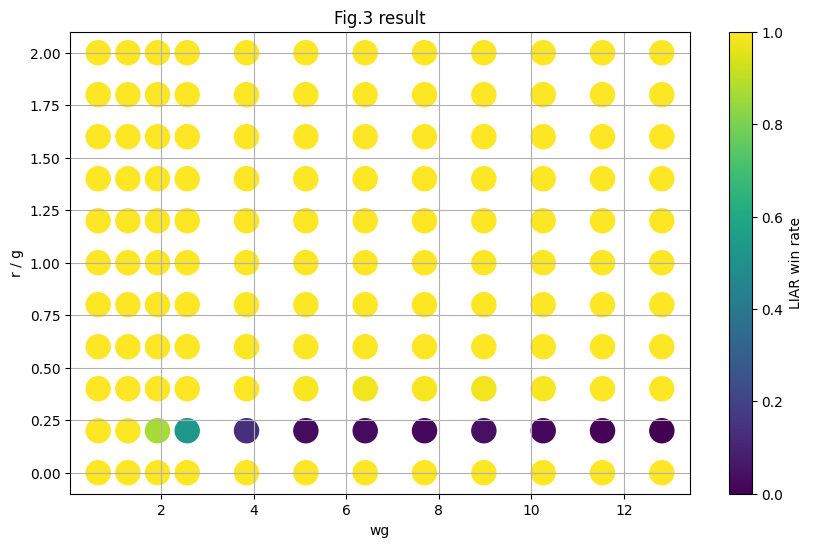

In [24]:
df_trials = pd.read_csv(CHECKPOINT_PATH)
df_fig3 = summarize_fig3_trials(
    df_trials,
    g=G,
    N=N,
    repeat=REPEAT
)

plt.figure(figsize=(10, 6))

plt.scatter(
    df_fig3["wg"],
    df_fig3["r_over_g"],
    c=df_fig3["liar_win_rate"],
    s=300,
    vmin=0,
    vmax=1
)

plt.colorbar(label="LIAR win rate")
plt.xlabel("wg")
plt.ylabel("r / g")
plt.title("Fig.3 result")
plt.grid(True)
plt.show()